In [ ]:
# ============================================================
# SETUP: Mount Drive, paths, install
# ============================================================
from google.colab import drive
drive.mount('/content/drive')

DATA_PATH  = "/content/drive/MyDrive/MSc_Dissertation/data/"
MODEL_PATH = "/content/drive/MyDrive/MSc_Dissertation/models/"

!pip install xgboost imbalanced-learn shap -q

Mounted at /content/drive


In [ ]:
# ============================================================
# IMPORTS + CONFIG + HELPERS
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap, pickle, time, warnings
from IPython.display import display
from sklearn.model_selection import train_test_split
warnings.filterwarnings('ignore')
np.random.seed(42)

# ---- Config ----
RF_SAMPLE_N = 2000   # rows for RF TreeSHAP (depth-20 trees -> subsample for speed)
EVAL_N      = 500    # canonical instance set scored by ALL models (reused Day 3/4)
BG_N        = 100    # background size for probability-space + linear explainers

def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))

def churn_class(raw):
    """Return 2D churn-class SHAP array across list / 2D / 3D shap formats."""
    if isinstance(raw, list):
        return np.asarray(raw[1])
    raw = np.asarray(raw)
    return raw[:, :, 1] if raw.ndim == 3 else raw

def to_scalar(v):
    a = np.ravel(v)
    return float(a[0]) if a.size == 1 else float(a[-1])   # last = churn class

In [ ]:
# ============================================================
# STEP 1: LOAD DAY 1 ARTIFACTS + PICK BEST MODEL + EVAL SET
# ============================================================
print("="*60); print("STEP 1: LOADING MODELS AND DATA"); print("="*60)

xgb_model = pickle.load(open(MODEL_PATH + 'xgboost_tuned.pkl', 'rb'))
lr_model  = pickle.load(open(MODEL_PATH + 'logistic_regression_tuned.pkl', 'rb'))
rf_model  = pickle.load(open(MODEL_PATH + 'random_forest_tuned.pkl', 'rb'))
test_data = pickle.load(open(MODEL_PATH + 'test_data.pkl', 'rb'))

X_test_scaled     = test_data['X_test_scaled']
y_test            = test_data['y_test']
X_train_resampled = test_data['X_train_resampled']
feature_names     = test_data['feature_names']
print(f"Test set: {X_test_scaled.shape[0]:,} rows × {X_test_scaled.shape[1]} features")

# Confirm the best-performing model (SHAP/LIME deep-dive centres on it, per proposal)
try:
    res = pd.read_csv(MODEL_PATH + 'model_comparison_results.csv', index_col=0)
    best_model_name = res['AUC-ROC'].idxmax()
    print(f"Best model by test AUC: {best_model_name} ({res.loc[best_model_name,'AUC-ROC']:.4f})")
except Exception:
    best_model_name = 'XGBoost'
    print("Comparison CSV not found — defaulting deep-dive to XGBoost.")

# Canonical evaluation set — SAME customers scored by every model (fair comparison)
_, eval_X = train_test_split(X_test_scaled, test_size=EVAL_N,
                             stratify=y_test, random_state=42)
eval_idx = eval_X.index
print(f"Canonical eval set: {len(eval_idx)} rows ({y_test.loc[eval_idx].mean()*100:.1f}% churn)")

# Shared background for probability-space / linear explainers
background = shap.sample(X_test_scaled, BG_N, random_state=42)

STEP 1: LOADING MODELS AND DATA
Test set: 21,315 rows × 66 features
Best model by test AUC: XGBoost (0.6799)
Canonical eval set: 500 rows (29.0% churn)


In [ ]:
# ============================================================
# STEP 2: XGBOOST TreeSHAP — exact, log-odds space, full test set
#   This is the primary explanation target + Day 4 fidelity source
# ============================================================
print("\n"+"="*60); print("STEP 2: XGBOOST TreeSHAP (exact)"); print("="*60)

t = time.time()
xgb_explainer = shap.TreeExplainer(xgb_model)
xgb_shap = churn_class(xgb_explainer.shap_values(X_test_scaled))
xgb_base = to_scalar(xgb_explainer.expected_value)
print(f"Done in {time.time()-t:.1f}s | shape {xgb_shap.shape} | base(log-odds) {xgb_base:.4f}")

xgb_shap_df = pd.DataFrame(xgb_shap, columns=feature_names, index=X_test_scaled.index)

# --- Faithfulness check across 100 rows (not just 1): sigmoid(base+sum) == P(churn) ---
chk = X_test_scaled.iloc[:100]
recon = sigmoid(xgb_shap_df.iloc[:100].sum(axis=1).values + xgb_base)
true_p = xgb_model.predict_proba(chk)[:, 1]
mae = np.mean(np.abs(recon - true_p))
print(f"XGBoost additivity MAE over 100 rows: {mae:.6f}  ->  {'PASS' if mae < 1e-3 else 'CHECK'}")


STEP 2: XGBOOST TreeSHAP (exact)
Done in 23.4s | shape (21315, 66) | base(log-odds) 0.0153
XGBoost additivity MAE over 100 rows: 0.000000  ->  PASS


In [ ]:
# ============================================================
# STEP 3: RANDOM FOREST TreeSHAP — probability space, stratified subsample
#   (depth-20 trees make full-set TreeSHAP take hours; 2k rows is stable)
# ============================================================
print("\n"+"="*60); print("STEP 3: RANDOM FOREST TreeSHAP (subsample)"); print("="*60)

# Build a 2k stratified sample that INCLUDES the eval set (so RF covers eval customers)
n_extra = max(0, RF_SAMPLE_N - len(eval_idx))
rem_X, rem_y = X_test_scaled.drop(index=eval_idx), y_test.drop(index=eval_idx)
if n_extra > 0:
    _, extra_X = train_test_split(rem_X, test_size=n_extra, stratify=rem_y, random_state=42)
    rf_sample_X = pd.concat([eval_X, extra_X]).sort_index()
else:
    rf_sample_X = eval_X.sort_index()

t = time.time()
rf_explainer = shap.TreeExplainer(rf_model)
rf_shap = churn_class(rf_explainer.shap_values(rf_sample_X, check_additivity=False))
rf_base = to_scalar(rf_explainer.expected_value)
print(f"Done in {time.time()-t:.1f}s | shape {rf_shap.shape} | base(prob) {rf_base:.4f}")

rf_shap_df = pd.DataFrame(rf_shap, columns=feature_names, index=rf_sample_X.index)

# --- Faithfulness check: base + sum == P(churn) directly (RF TreeSHAP is in prob space) ---
recon = rf_shap_df.loc[eval_idx].sum(axis=1).values + rf_base
true_p = rf_model.predict_proba(eval_X)[:, 1]
mae = np.mean(np.abs(recon - true_p))
print(f"RandomForest additivity MAE over eval set: {mae:.6f}  ->  {'PASS' if mae < 1e-2 else 'CHECK'}")


STEP 3: RANDOM FOREST TreeSHAP (subsample)
Done in 2185.1s | shape (2000, 66) | base(prob) 0.5001
RandomForest additivity MAE over eval set: 0.000000  ->  PASS


In [ ]:
# ============================================================
# STEP 4: LOGISTIC REGRESSION — LinearExplainer (EXACT for linear models)
#   Runs in ms; more accurate than KernelSHAP which only approximates it
# ============================================================
print("\n"+"="*60); print("STEP 4: LOGISTIC REGRESSION LinearExplainer (exact)"); print("="*60)

t = time.time()
lr_explainer = shap.LinearExplainer(lr_model, background)
lr_shap = churn_class(lr_explainer.shap_values(X_test_scaled))
lr_base = to_scalar(lr_explainer.expected_value)
print(f"Done in {time.time()-t:.1f}s | shape {lr_shap.shape} | base(log-odds) {lr_base:.4f}")

lr_shap_df = pd.DataFrame(lr_shap, columns=feature_names, index=X_test_scaled.index)

# --- Faithfulness check: sigmoid(base+sum) == P(churn) ---
recon = sigmoid(lr_shap_df.iloc[:100].sum(axis=1).values + lr_base)
true_p = lr_model.predict_proba(X_test_scaled.iloc[:100])[:, 1]
mae = np.mean(np.abs(recon - true_p))
print(f"LogReg additivity MAE over 100 rows: {mae:.6f}  ->  {'PASS' if mae < 1e-2 else 'CHECK'}")


STEP 4: LOGISTIC REGRESSION LinearExplainer (exact)
Done in 0.0s | shape (21315, 66) | base(log-odds) -0.0229
LogReg additivity MAE over 100 rows: 0.000000  ->  PASS



STEP 5: GLOBAL EXPLANATIONS


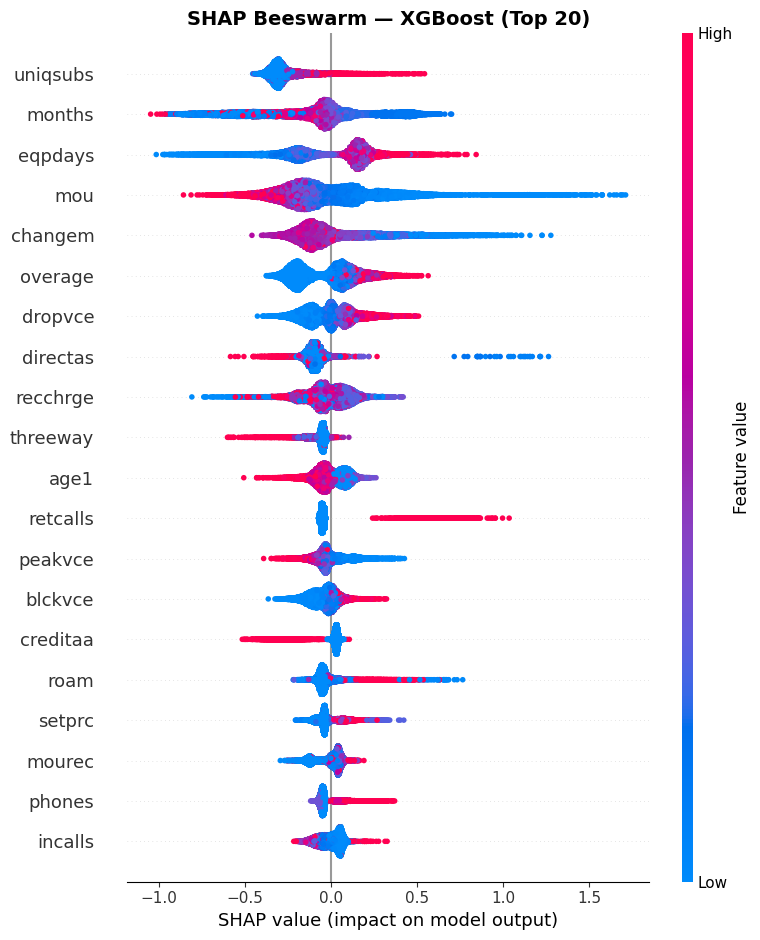

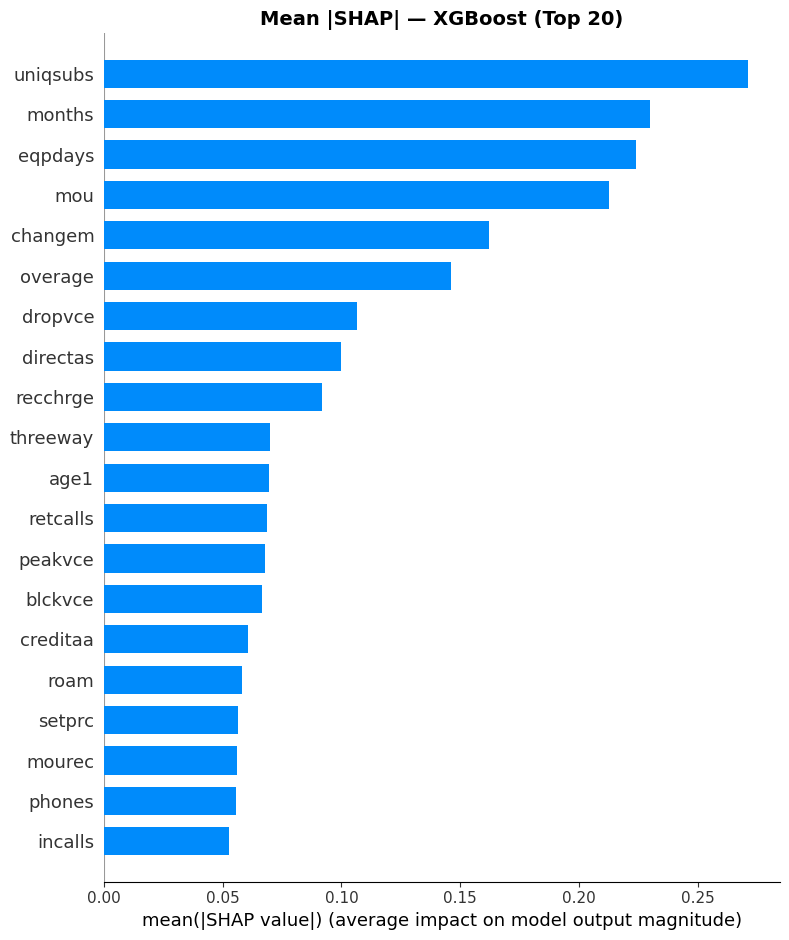

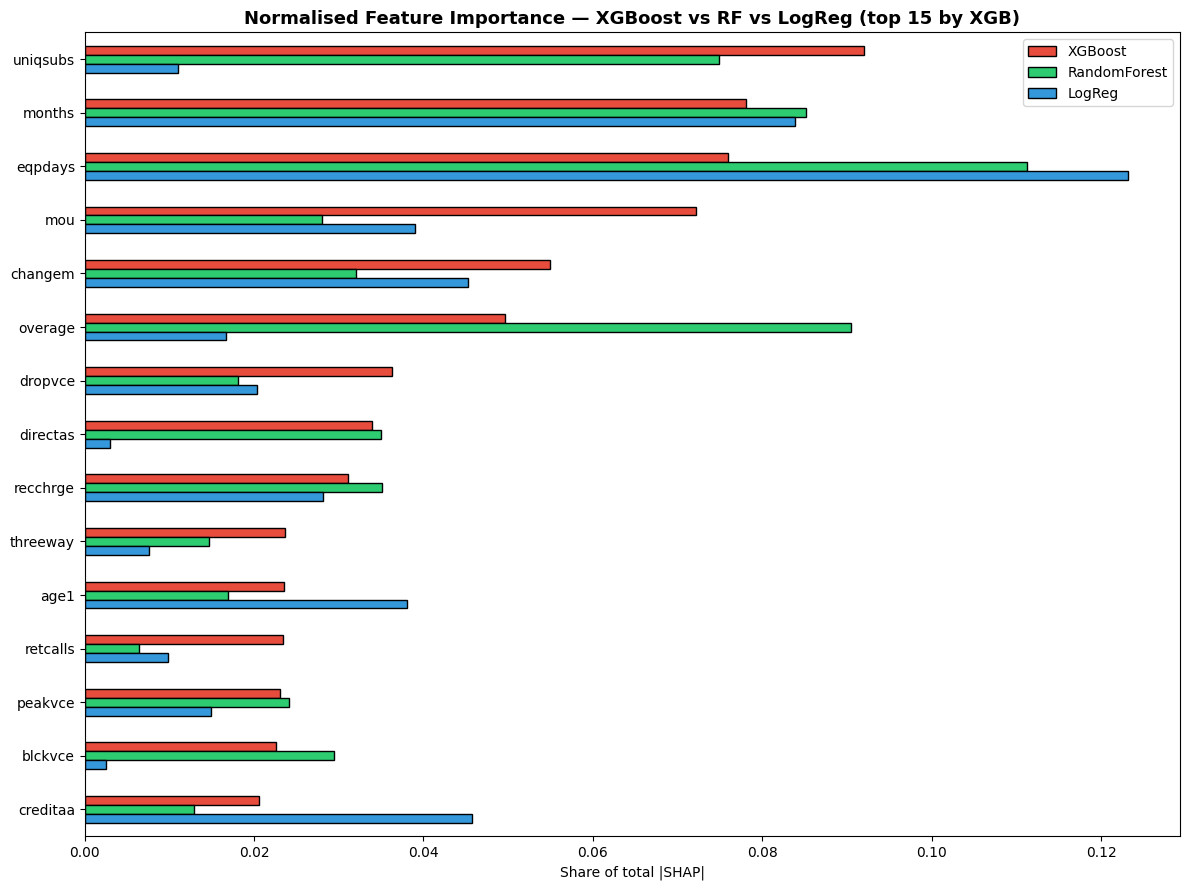


Top 10 XGBoost churn drivers:
   1. uniqsubs                 9.2%
   2. months                   7.8%
   3. eqpdays                  7.6%
   4. mou                      7.2%
   5. changem                  5.5%
   6. overage                  5.0%
   7. dropvce                  3.6%
   8. directas                 3.4%
   9. recchrge                 3.1%
  10. threeway                 2.4%


In [ ]:
# ============================================================
# STEP 5: GLOBAL EXPLANATIONS
#   Beeswarm + bar (XGBoost), and a FAIR normalised importance
#   comparison across all three models (rank/proportion based)
# ============================================================
print("\n"+"="*60); print("STEP 5: GLOBAL EXPLANATIONS"); print("="*60)

# Beeswarm (direction + magnitude per feature)
plt.figure(figsize=(12, 10))
shap.summary_plot(xgb_shap, X_test_scaled, feature_names=feature_names,
                  max_display=20, show=False)
plt.title("SHAP Beeswarm — XGBoost (Top 20)", fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

# Bar (mean |SHAP|)
plt.figure(figsize=(12, 8))
shap.summary_plot(xgb_shap, X_test_scaled, feature_names=feature_names,
                  plot_type="bar", max_display=20, show=False)
plt.title("Mean |SHAP| — XGBoost (Top 20)", fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

# Fair cross-model comparison: normalise each model's mean|SHAP| to sum to 1,
# so proportions are comparable despite different output spaces.
def norm_imp(shap_arr):
    m = np.abs(shap_arr).mean(axis=0)
    return pd.Series(m / m.sum(), index=feature_names)

imp = pd.DataFrame({
    'XGBoost': norm_imp(xgb_shap),
    'RandomForest': norm_imp(rf_shap),
    'LogReg': norm_imp(lr_shap),
})
top_feats = imp['XGBoost'].sort_values(ascending=False).head(15).index
imp.loc[top_feats].plot(kind='barh', figsize=(12, 9),
                        color=['#e74c3c','#2ecc71','#3498db'], edgecolor='black')
plt.gca().invert_yaxis()
plt.title('Normalised Feature Importance — XGBoost vs RF vs LogReg (top 15 by XGB)',
          fontsize=13, fontweight='bold')
plt.xlabel('Share of total |SHAP|'); plt.tight_layout(); plt.show()

xgb_top = imp['XGBoost'].sort_values(ascending=False)
print("\nTop 10 XGBoost churn drivers:")
for i in range(10):
    print(f"  {i+1:2d}. {xgb_top.index[i]:<22} {xgb_top.values[i]*100:5.1f}%")


STEP 6: LOCAL EXPLANATIONS (probability space)
  High-Risk Churner: P(churn)=0.932, Actual=Churn
  Borderline Churner: P(churn)=0.500, Actual=Churn
  Confident Non-Churner: P(churn)=0.019, Actual=Non-Churn
  Missed Churner (False Negative): P(churn)=0.034, Actual=Churn

Waterfall plots (values in probability space)...


  0%|          | 0/1 [00:00<?, ?it/s]

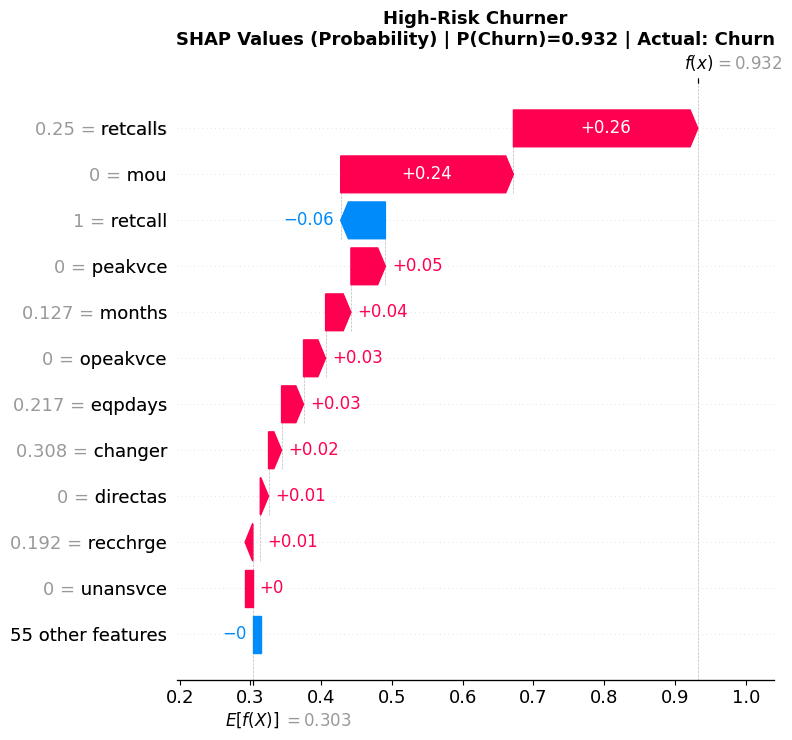

  0%|          | 0/1 [00:00<?, ?it/s]

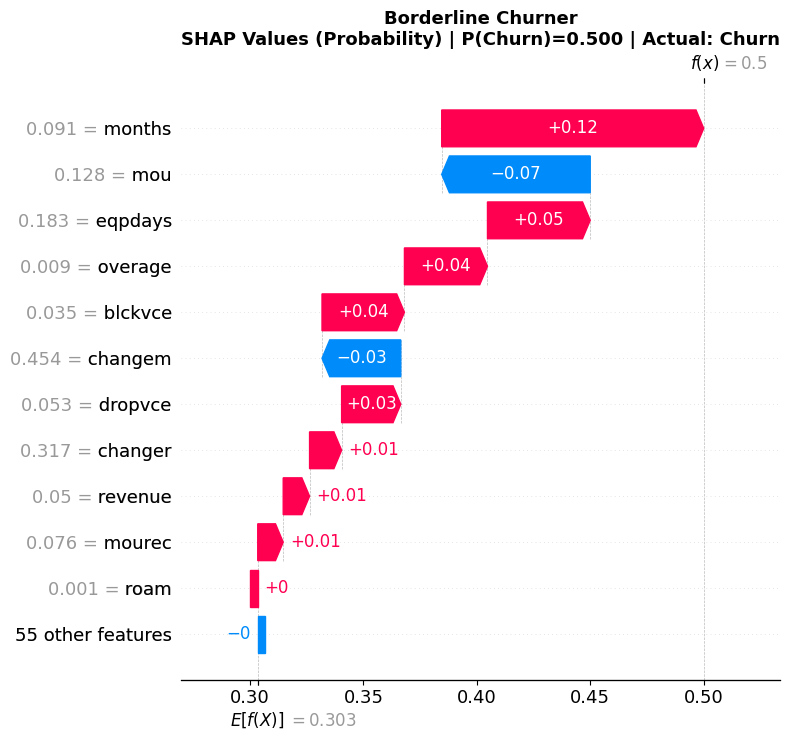

  0%|          | 0/1 [00:00<?, ?it/s]

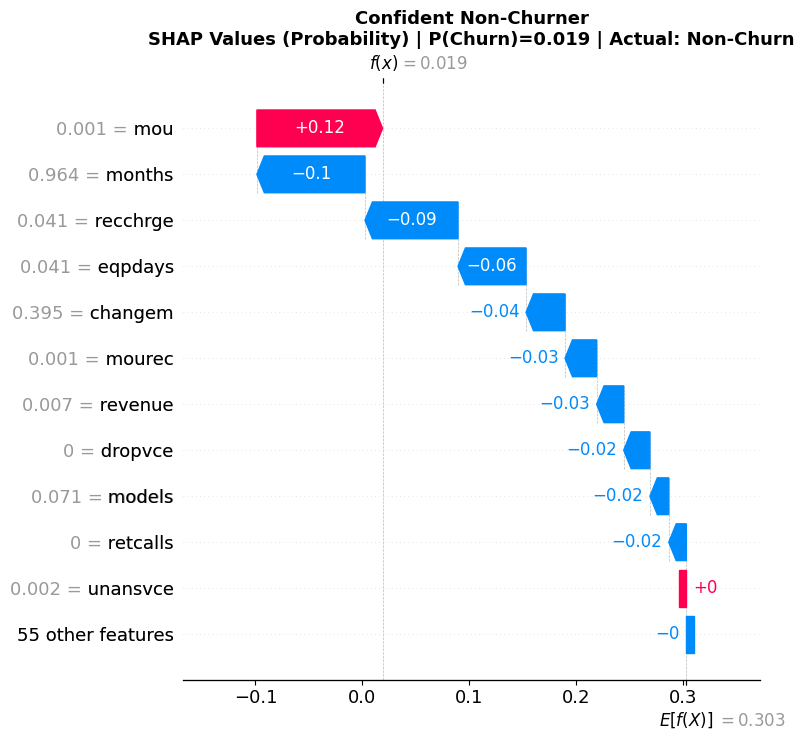

  0%|          | 0/1 [00:00<?, ?it/s]

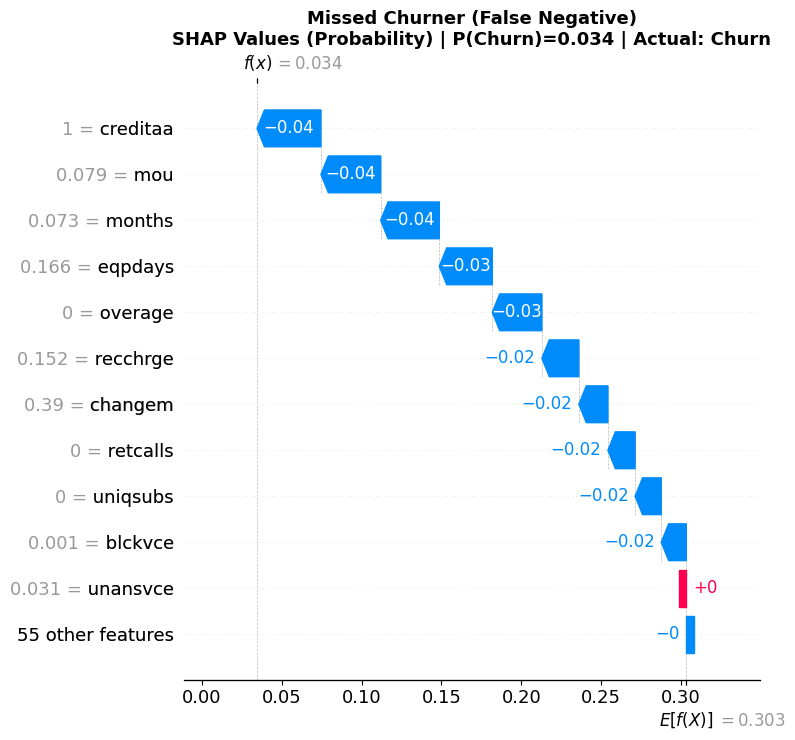

In [ ]:
# ============================================================
# STEP 6: LOCAL EXPLANATIONS — PROBABILITY SPACE (marketer-friendly)
#   Contributions here SUM TO P(churn) (approx), converted from log-odds.
# ============================================================
print("\n"+"="*60); print("STEP 6: LOCAL EXPLANATIONS (probability space)"); print("="*60)

# Use KernelExplainer for robustness with categorical features and direct probability explanation.
# It explains the probability of churn (positive class) directly.
xgb_prob_expl = shap.KernelExplainer(lambda x: xgb_model.predict_proba(x)[:, 1], background, link='identity')
prob_base = xgb_prob_expl.expected_value # KernelExplainer's expected_value for a single output

probs = pd.Series(xgb_model.predict_proba(X_test_scaled)[:, 1], index=X_test_scaled.index)
churn_ix, safe_ix = y_test[y_test==1].index, y_test[y_test==0].index
examples = {
    'High-Risk Churner':               probs[churn_ix].idxmax(),
    'Borderline Churner':              (probs[churn_ix]-0.5).abs().idxmin(),
    'Confident Non-Churner':            probs[safe_ix].idxmin(),
    'Missed Churner (False Negative)':  probs[churn_ix].idxmin(),
}
for label, idx in examples.items():
    print(f"  {label}: P(churn)={probs[idx]:.3f}, Actual={'Churn' if y_test[idx]==1 else 'Non-Churn'}")

print("\nWaterfall plots (values in probability space)...") # Updated description for KernelExplainer
for label, idx in examples.items():
    row = X_test_scaled.loc[[idx]]
    sv = xgb_prob_expl.shap_values(row) # KernelExplainer returns a 2D array of shape (1, n_features) for a single row
    plt.figure(figsize=(12, 6))
    shap.waterfall_plot(shap.Explanation(values=sv[0], base_values=prob_base, # Extract the 1D array from sv
                        data=row.values[0], feature_names=feature_names),
                        max_display=12, show=False)
    plt.title(f'{label}\nSHAP Values (Probability) | P(Churn)={probs[idx]:.3f} | Actual: ' # Updated title
              f'{"Churn" if y_test[idx]==1 else "Non-Churn"}', fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.show()


STEP 7: DEPENDENCE + INTERACTIONS


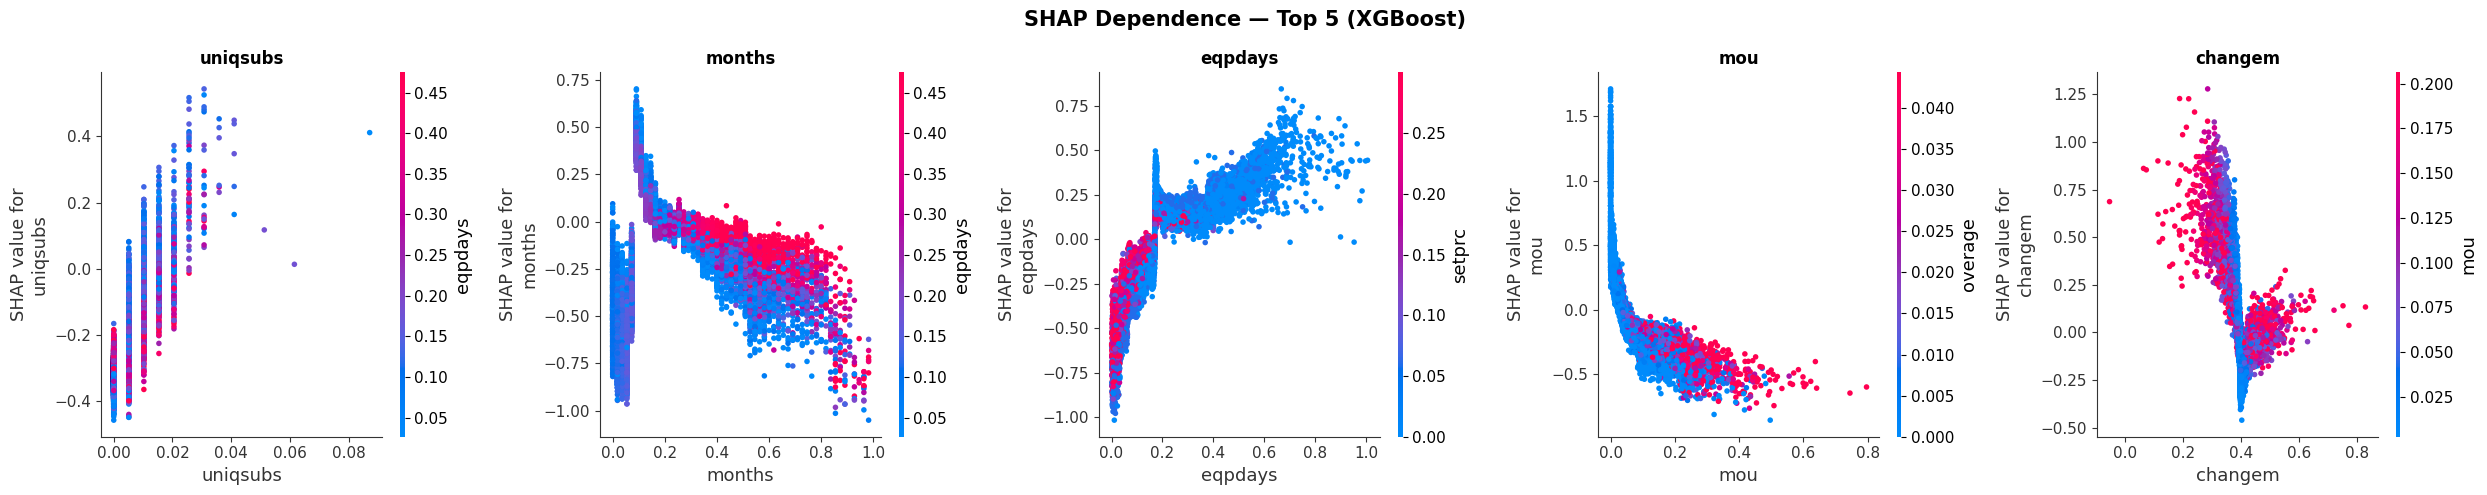

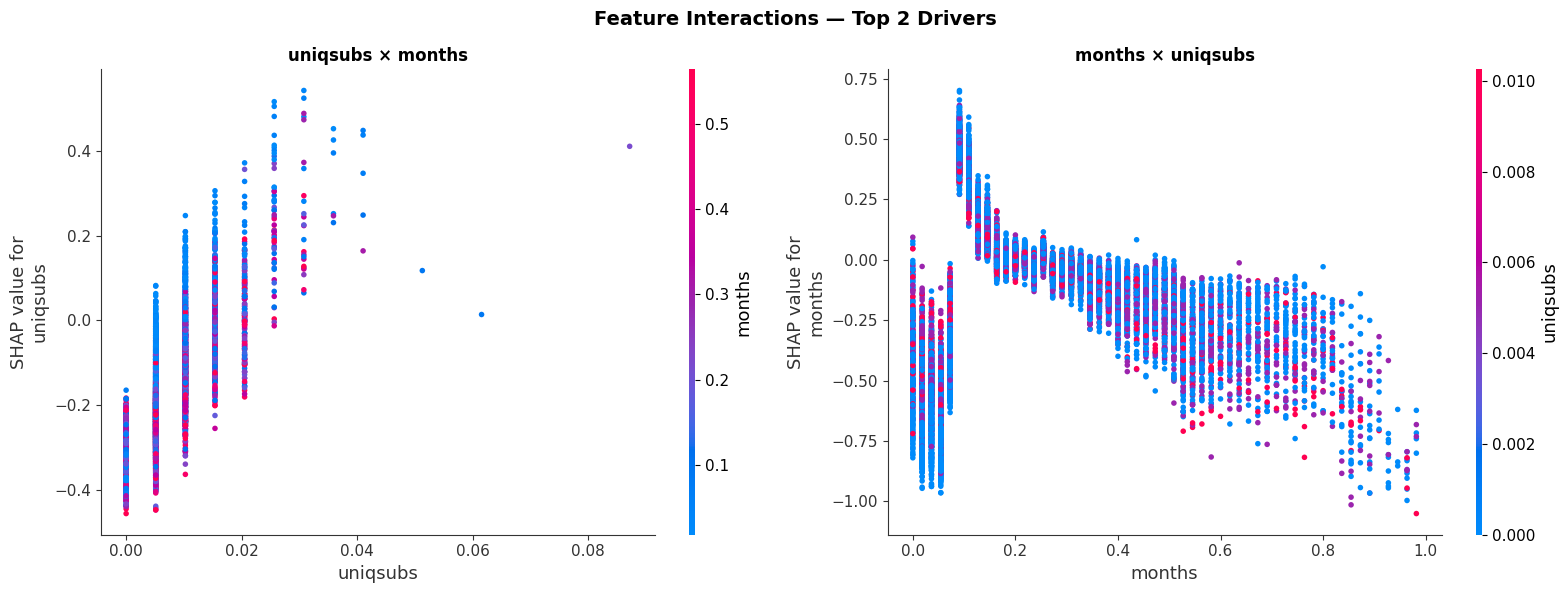

In [ ]:
# ============================================================
# STEP 7: DEPENDENCE (top 5) + INTERACTION (top 2)  — XGBoost, log-odds SHAP
# ============================================================
print("\n"+"="*60); print("STEP 7: DEPENDENCE + INTERACTIONS"); print("="*60)

top5 = xgb_top.index[:5].tolist()
fig, axes = plt.subplots(1, 5, figsize=(25, 5))
for ax, f in zip(axes, top5):
    shap.dependence_plot(f, xgb_shap, X_test_scaled, feature_names=feature_names,
                         ax=ax, show=False)
    ax.set_title(f, fontweight='bold')
plt.suptitle('SHAP Dependence — Top 5 (XGBoost)', fontsize=15, fontweight='bold')
plt.tight_layout(); plt.show()

t2 = top5[:2]
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
shap.dependence_plot(t2[0], xgb_shap, X_test_scaled, interaction_index=t2[1],
                     feature_names=feature_names, ax=axes[0], show=False)
axes[0].set_title(f'{t2[0]} × {t2[1]}', fontweight='bold')
shap.dependence_plot(t2[1], xgb_shap, X_test_scaled, interaction_index=t2[0],
                     feature_names=feature_names, ax=axes[1], show=False)
axes[1].set_title(f'{t2[1]} × {t2[0]}', fontweight='bold')
plt.suptitle('Feature Interactions — Top 2 Drivers', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

In [ ]:
# ============================================================
# STEP 8: SAVE OUTPUTS
#   - eval SHAP per model (Day 4 agreement, SAME customers)
#   - full XGB SHAP (Day 6 segmentation)
#   - normalised importance table + eval_idx
# ============================================================
print("\n"+"="*60); print("STEP 8: SAVING OUTPUTS"); print("="*60)

shap_outputs = {
    'xgb_shap': xgb_shap, 'xgb_base': xgb_base,
    'rf_shap': rf_shap,   'rf_base': rf_base, 'rf_sample_idx': rf_sample_X.index.tolist(),
    'lr_shap': lr_shap,   'lr_base': lr_base,
    'eval_idx': list(eval_idx), 'feature_names': feature_names,
    'examples': examples, 'best_model': best_model_name,
    'lr_method': 'LinearExplainer', 'importance_norm': imp,
}
pickle.dump(shap_outputs, open(MODEL_PATH + 'shap_outputs.pkl', 'wb'))
print("Saved: shap_outputs.pkl")

# Per-model SHAP on the SAME eval customers -> Day 4 agreement metric
xgb_shap_df.loc[eval_idx].to_csv(MODEL_PATH + 'xgb_shap_eval.csv')
rf_shap_df.loc[eval_idx].to_csv(MODEL_PATH + 'rf_shap_eval.csv')
lr_shap_df.loc[eval_idx].to_csv(MODEL_PATH + 'lr_shap_eval.csv')
# Full XGB SHAP -> Day 6 segmentation (clusters churners on SHAP vectors)
xgb_shap_df.to_csv(MODEL_PATH + 'xgb_shap_values.csv')
imp.to_csv(MODEL_PATH + 'shap_importance_normalised.csv')
print("Saved: xgb/rf/lr_shap_eval.csv, xgb_shap_values.csv, shap_importance_normalised.csv")


STEP 8: SAVING OUTPUTS
Saved: shap_outputs.pkl
Saved: xgb/rf/lr_shap_eval.csv, xgb_shap_values.csv, shap_importance_normalised.csv


In [ ]:
# ============================================================
# STEP 9: SUMMARY
# ============================================================
print("\n"+"="*60); print("DAY 2 SUMMARY"); print("="*60)
print(f"""
Explainers (exact where possible):
  XGBoost      -> TreeSHAP, full test, log-odds     top3: {', '.join(xgb_top.index[:3])}
  RandomForest -> TreeSHAP, {rf_shap.shape[0]}-row sample, prob
  LogReg       -> LinearExplainer (exact), log-odds

Faithfulness (additivity) validated per model above (see PASS flags).
Local marketer plots rendered in PROBABILITY space (sum to P(churn)).
Canonical eval set: {len(eval_idx)} rows — SAME customers across all models.

Saved for downstream:
  Day 4 agreement -> xgb/rf/lr_shap_eval.csv
  Day 6 segments  -> xgb_shap_values.csv
NEXT: Day 3 — LIME on the SAME eval set ({len(eval_idx)} rows)
""")
print("DAY 2 COMPLETE.")


DAY 2 SUMMARY

Explainers (exact where possible):
  XGBoost      -> TreeSHAP, full test, log-odds     top3: uniqsubs, months, eqpdays
  RandomForest -> TreeSHAP, 2000-row sample, prob
  LogReg       -> LinearExplainer (exact), log-odds

Faithfulness (additivity) validated per model above (see PASS flags).
Local marketer plots rendered in PROBABILITY space (sum to P(churn)).
Canonical eval set: 500 rows — SAME customers across all models.

Saved for downstream:
  Day 4 agreement -> xgb/rf/lr_shap_eval.csv
  Day 6 segments  -> xgb_shap_values.csv
NEXT: Day 3 — LIME on the SAME eval set (500 rows)

DAY 2 COMPLETE.
